# Lead Quality Analysis Case Study


In [1]:

!pip install xlrd openpyxl scipy seaborn scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, linregress
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
print("Libraries Loaded")


Libraries Loaded


In [2]:

from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)

print(df.shape)
df.head()


Saving Analyst_case_study_dataset_1.xls to Analyst_case_study_dataset_1.xls
(3021, 24)


,LeadCreated,FirstName,Email,VendorLeadID,CallStatus,WidgetName,PublisherZoneName,PublisherCampaignName,AddressScore,PhoneScore,AdvertiserCampaignName,State,DebtLevel,IP Address,Partner,ReferralDomain,MarketingCampaign,AdGroup,Keyword,SearchQuery,ReferralURL,ReferralURL Parameters,LandingPageURL,Landing Page URL Parameters
0,2009-07-01 01:24:29.563,Dorinda,kanani@sandwichisles.net,FDF81FDA-A649-437B-B99C-FDDE74F7971B,NaN,w-302252-DebtReduction1-1DC-CreditSolutions,TopLeft-302252,DebtReductionInc,NaN,5.0,creditsolutions-branded-shortform,HI,30001-50000,NaN,google,www.google.com,Debt Holding Tank,Holding Tank - Debt,Debt specialists,debt specialists,http://www.google.com/search,sourceid=navclient&aq=1&oq=debt sp&ie=UTF-8&rl...,http://www.debtreductioninc.com/index8.html,utm_source=google&utm_medium=CPC&utm_content=H...
1,2009-04-13 15:27:35.990,Presetta,clerk2@ustconline.net,4190ACB7-5026-416C-B987-ED8AD427D5E6,NaN,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,Debt Settlement1 Master,AL,90000-100000,NaN,AdKnowledge,NaN,Financial Services,Consolidate,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...
2,2009-04-21 07:22:59.000,Gina,wagoner_gina@yahoo.com,hFg80jf_R0CRN55hdhWILw,Unable to contact - Bad Contact Information,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,Debt Settlement1 Master,NY,20001-30000,NaN,AdKnowledge,us.mc582.mail.yahoo.com,Financial Services,Consolidate,NaN,NaN,http://us.mc582.mail.yahoo.com/mc/showMessage,&fid=Inbox&sort=date&order=down&startMid=0&.ra...,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...
3,2009-08-03 19:39:02.000,Kari,usa4ley@yahoo.com,jB01QgYZxkWArI9jWxuufw,Contacted - Doesn't Qualify,w-302252-DebtReduction1-1DC-white,TopLeft-302252,DebtReductionInc,5.0,3.0,Debt Settlement1 Master,WA,20001-30000,NaN,Google,norwich.kijiji.com,DebtReductionInc,Lower Payments,NaN,NaN,http://norwich.kijiji.com/c-Cars-vehicles-Cars...,NaN,http://www.debtreductioninc.com/index12.html,utm_source=Google&utm_medium=cpc&utm_campaign=...
4,2009-04-13 10:18:37.490,Stephanie,sr1lambert@embarqmail.com,D5B32074-458E-40EC-B185-1FEF20AC626D,NaN,w-300250-DebtReduction1-1DC-BlueMeter,TopLeft-302252,DebtReductionInc,NaN,NaN,Debt Settlement1 Master,TX,More_than_100000,NaN,Google,NaN,DebtReductionInc,Debt Reduction,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=Google&utm_medium=cpc&utm_campaign=...


In [3]:

df.info()
df.isnull().sum().sort_values(ascending=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3021 entries, 0 to 3020
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   LeadCreated                  3021 non-null   datetime64[ns]
 1   FirstName                    3021 non-null   object        
 2   Email                        3021 non-null   object        
 3   VendorLeadID                 3013 non-null   object        
 4   CallStatus                   881 non-null    object        
 5   WidgetName                   3021 non-null   object        
 6   PublisherZoneName            3021 non-null   object        
 7   PublisherCampaignName        3021 non-null   object        
 8   AddressScore                 1171 non-null   float64       
 9   PhoneScore                   1393 non-null   float64       
 10  AdvertiserCampaignName       3021 non-null   object        
 11  State                        3021 non-null 

,0
IP Address,3021
CallStatus,2140
Keyword,2042
AddressScore,1850
SearchQuery,1756
PhoneScore,1628
ReferralURL Parameters,738
ReferralURL,515
ReferralDomain,515
MarketingCampaign,272


In [4]:

print(df.columns.tolist())


['LeadCreated', 'FirstName', 'Email', 'VendorLeadID', 'CallStatus', 'WidgetName', 'PublisherZoneName', 'PublisherCampaignName', 'AddressScore', 'PhoneScore', 'AdvertiserCampaignName', 'State', 'DebtLevel', 'IP Address', 'Partner', 'ReferralDomain', 'MarketingCampaign', 'AdGroup', 'Keyword', 'SearchQuery', 'ReferralURL', 'ReferralURL Parameters', 'LandingPageURL', 'Landing Page URL Parameters']


In [5]:

df['CallStatus'].value_counts(dropna=False)


,count
CallStatus,
NaN,2140
Closed,245
Contacted - Doesn't Qualify,212
Unable to contact - Bad Contact Information,191
EP Confirmed,130
Contacted - Invalid Profile,85
EP Sent,16
EP Received,2


## Create Lead Quality Flags

In [6]:

good_status = ['Closed','EP Sent','EP Received','EP Confirmed']

bad_status = [
    'Unable to contact - Bad Contact Information',
    'Contacted - Invalid Profile',
    "Contacted - Doesn't Qualify"
]

def classify(status):
    if pd.isna(status):
        return 'Unknown'
    if status in good_status:
        return 'Good'
    elif status in bad_status:
        return 'Bad'
    return 'Unknown'

df['LeadQuality'] = df['CallStatus'].apply(classify)
df['ClosedFlag'] = (df['CallStatus'] == 'Closed').astype(int)

df['LeadQuality'].value_counts()


,count
LeadQuality,
Unknown,2140
Bad,488
Good,393


In [7]:

overall_quality = (df['LeadQuality']=='Good').mean()*100
closed_rate = df['ClosedFlag'].mean()*100

print("Overall Quality %:", round(overall_quality,2))
print("Closed Rate %:", round(closed_rate,2))


Overall Quality %: 13.01
Closed Rate %: 8.11


## Trend Analysis

In [8]:

date_col = df.columns[0]

df[date_col] = pd.to_datetime(df[date_col])
df['Month'] = df[date_col].dt.to_period('M')

monthly = df.groupby('Month').agg(
    TotalLeads=('VendorLeadID','count'),
    GoodLeads=('LeadQuality', lambda x:(x=='Good').sum()),
    ClosedLeads=('ClosedFlag','sum')
)

monthly['QualityRate'] = monthly['GoodLeads']/monthly['TotalLeads']
monthly['CloseRate'] = monthly['ClosedLeads']/monthly['TotalLeads']

monthly.head()


,TotalLeads,GoodLeads,ClosedLeads,QualityRate,CloseRate
Month,,,,,
2009-04,517,79,56,0.152805,0.108317
2009-05,579,59,37,0.101900,0.063903
2009-06,606,86,63,0.141914,0.103960
2009-07,531,49,33,0.092279,0.062147
2009-08,436,62,41,0.142202,0.094037


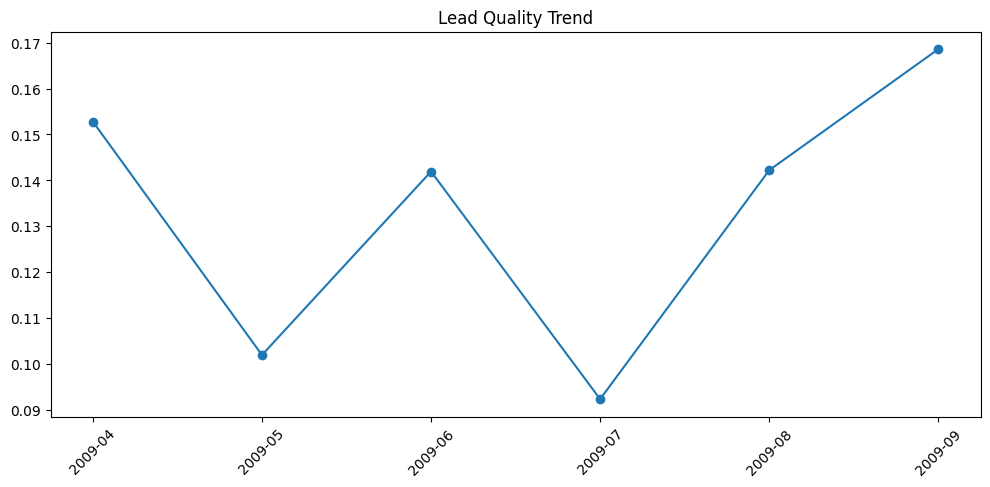

In [9]:

plt.figure(figsize=(12,5))
plt.plot(monthly.index.astype(str), monthly['QualityRate'], marker='o')
plt.xticks(rotation=45)
plt.title('Lead Quality Trend')
plt.show()


In [10]:

trend = monthly.reset_index()
trend['MonthNum'] = range(len(trend))

result = linregress(trend['MonthNum'], trend['QualityRate'])
print(result)


LinregressResult(slope=np.float64(0.00429344559092356), intercept=np.float64(0.12255036373876677), rvalue=np.float64(0.2692732667672198), pvalue=np.float64(0.6058523452754395), stderr=np.float64(0.007677817651764899), intercept_stderr=np.float64(0.02324574733206197))


## Driver Analysis Function

In [11]:

def segment_analysis(column):

    temp = df.groupby(column).agg(
        Leads=('VendorLeadID','count'),
        Good=('LeadQuality', lambda x:(x=='Good').sum()),
        Closed=('ClosedFlag','sum')
    )

    temp = temp[temp['Leads'] >= 30]

    temp['QualityRate'] = temp['Good']/temp['Leads']
    temp['CloseRate'] = temp['Closed']/temp['Leads']

    return temp.sort_values('QualityRate', ascending=False)



In [12]:

for col in ['WidgetName',
            'Partner',
            'State',
            'DebtLevel',
            'AddressScore',
            'PhoneScore',
            'Campaign']:

    if col in df.columns:
        print("\n", col)
        display(segment_analysis(col).head(10))



 WidgetName


,Leads,Good,Closed,QualityRate,CloseRate
WidgetName,,,,,
w-302252-DebtReduction1-1DC-yellowarrow,49,12,3,0.244898,0.061224
w-300250-DebtReduction1-1DC-CreditSolutions,76,18,12,0.236842,0.157895
w-300250-DebtReduction1-1DC,348,56,34,0.160920,0.097701
w-300250-DebtReduction1-1DC-Head2,89,14,11,0.157303,0.123596
w-300250-DebtReduction1-1DC-BlueMeter,92,14,13,0.152174,0.141304
w-300250-DebtReduction1-2DC-BlueMeter,87,12,6,0.137931,0.068966
w-302252-DebtReduction1-1DC-yellowarrow-blue,230,31,15,0.134783,0.065217
w-302252-DebtReduction1-1DC-CreditSolutions,1052,131,76,0.124525,0.072243
w-302252-DebtReduction1-1DC,271,32,23,0.118081,0.084871



 Partner


,Leads,Good,Closed,QualityRate,CloseRate
Partner,,,,,
AdKnowledge,171,32,21,0.187135,0.122807
Call_Center,271,44,26,0.162362,0.095941
yahoo,955,136,74,0.142408,0.077487
google,977,135,97,0.138178,0.099284
Google,636,45,26,0.070755,0.040881



 State


...

,Leads,Good,Closed,QualityRate,CloseRate
DebtLevel,,,,,
70001-90000,131,25,18,0.190840,0.137405
10001-15000,291,54,34,0.185567,0.116838
20001-30000,454,72,40,0.158590,0.088106
50001-70000,244,38,22,0.155738,0.090164
15001-20000,408,57,35,0.139706,0.085784
30001-50000,495,61,39,0.123232,0.078788
90000-100000,90,11,9,0.122222,0.100000
7500-15000,270,31,19,0.114815,0.070370
7500-10000,440,31,22,0.070455,0.050000



 AddressScore


,Leads,Good,Closed,QualityRate,CloseRate
AddressScore,,,,,
2.0,38,7,4,0.184211,0.105263
5.0,868,120,64,0.138249,0.073733
1.0,122,14,5,0.114754,0.040984
3.0,93,9,5,0.096774,0.053763
4.0,48,2,1,0.041667,0.020833



 PhoneScore


,Leads,Good,Closed,QualityRate,CloseRate
PhoneScore,,,,,
5.0,619,100,54,0.161551,0.087237
3.0,426,50,28,0.117371,0.065728
2.0,160,16,7,0.100000,0.043750
4.0,184,13,7,0.070652,0.038043


## Statistical Significance Tests

In [13]:

test_cols = ['WidgetName','Partner','State','DebtLevel','Campaign']

for col in test_cols:

    if col in df.columns:

        table = pd.crosstab(df[col], df['LeadQuality'])

        chi2,p,dof,expected = chi2_contingency(table)

        print(col, "P Value =", p)


WidgetName P Value = 1.2663439939589191e-05
Partner P Value = 3.0638843303121117e-07
State P Value = 0.7169998427961211
DebtLevel P Value = 6.999604037393795e-09


## Address and Phone Score Quality

In [14]:

if 'AddressScore' in df.columns:
    print(df.groupby('AddressScore')['ClosedFlag'].mean())

if 'PhoneScore' in df.columns:
    print(df.groupby('PhoneScore')['ClosedFlag'].mean())


AddressScore
1.0    0.040984
2.0    0.105263
3.0    0.053763
4.0    0.020833
5.0    0.073563
Name: ClosedFlag, dtype: float64
PhoneScore
1.0    0.000000
2.0    0.043210
3.0    0.065574
4.0    0.038043
5.0    0.087237
Name: ClosedFlag, dtype: float64


## Machine Learning Feature Importance

In [15]:

model_df = df.copy()

model_df['Target'] = (model_df['LeadQuality']=='Good').astype(int)

candidate_cols = []

for col in ['WidgetName','Partner','State','Campaign',
            'AddressScore','PhoneScore','DebtLevel']:

    if col in model_df.columns:
        candidate_cols.append(col)

X = pd.get_dummies(model_df[candidate_cols], dummy_na=True)
y = model_df['Target']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
}).sort_values('Importance',ascending=False)

importance.head(20)


,Feature,Importance
1,PhoneScore,0.070691
0,AddressScore,0.045597
11,WidgetName_w-302252-DebtReduction1-1DC-CreditS...,0.038787
21,Partner_google,0.035276
22,Partner_yahoo,0.034380
28,State_CA,0.034274
52,State_TX,0.029831
59,DebtLevel_20001-30000,0.028345
60,DebtLevel_30001-50000,0.028074
58,DebtLevel_15001-20000,0.027476


In [16]:

df.to_csv('cleaned_leads.csv', index=False)

from google.colab import files
files.download('cleaned_leads.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>